# Symmetric Clausius Quarkyonic EOS

This notebook builds the **symmetric-matter** quarkyonic EOS for the Clausius model only.
It reuses the exact Clausius branches already fitted to selected target values of `K0` and does not modify the asymmetric notebooks.

In [4]:
from dataclasses import asdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path("/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows")
results_root = repo_root / "results"
results_root.mkdir(parents=True, exist_ok=True)

asym_src = repo_root / "asymmetric_clausius_fit" / "src"
ground_src = repo_root / "ground_state_ab_k0" / "src"
quark_src = repo_root / "quarkyonic_sound_speed_vs2" / "src"

for path in [str(asym_src), str(ground_src), str(quark_src)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from asymmetric_clausius_fit import DEFAULT_CONSTANTS, compute_target_family
from quarkyonic_sound_speed_vs2 import QuarkyonicSettings, compute_quarkyonic_sound_speed_curve
from quarkyonic_sound_speed_vs2.reporting import curve_to_records

pd.set_option("display.precision", 6)

output_dir = results_root / "symmetric_clausius_quarkyonic_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

ACTIVE_TARGET_K0S = [250.0, 280.0, 315.0]

# Use QuarkyonicSettings() for a denser production run.
SETTINGS = QuarkyonicSettings.quick()

output_dir


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/symmetric_clausius_quarkyonic_outputs')

The Clausius `c` values are taken from the exact `K0`-targeted Clausius family already constructed in the workflow.
That gives an exact symmetric branch for each selected `K0`, instead of relying on the older coarse `c` scan.

In [5]:
fit_csv = results_root / "asymmetric_clausius_fit_results.csv"

if fit_csv.exists():
    fit_df = pd.read_csv(fit_csv)
else:
    fit_df = pd.DataFrame(asdict(result) for result in compute_target_family(ACTIVE_TARGET_K0S, DEFAULT_CONSTANTS))
    fit_df.to_csv(fit_csv, index=False)

target_df = fit_df[fit_df["target_k0"].isin(ACTIVE_TARGET_K0S)].copy()
target_df = target_df.sort_values("target_k0").reset_index(drop=True)

display(target_df[["target_k0", "K0", "c", "a_avg", "b_avg"]])


,target_k0,K0,c,a_avg,b_avg
0,250.0,250.000002,4.735853,472.327508,1.727371
1,280.0,280.000000,4.114108,454.412697,1.936450
2,315.0,314.999999,3.507371,436.714809,2.143624


In [6]:
curve_map = {}
summary_rows = []
all_curve_rows = []

for row in target_df.itertuples(index=False):
    label = f"k0_{int(round(float(row.target_k0)))}"
    curve = compute_quarkyonic_sound_speed_curve("clausius", par=float(row.c), settings=SETTINGS)
    if curve is None:
        continue

    curve_map[label] = curve

    summary_rows.append(
        {
            "label": label,
            "target_k0": float(row.target_k0),
            "fit_K0": float(row.K0),
            "c": float(row.c),
            "a_avg_fit": float(row.a_avg),
            "b_avg_fit": float(row.b_avg),
            "a_curve": float(curve.a),
            "b_curve": float(curve.b),
            "K0_curve": float(curve.K0),
            "vs2_max": float(curve.vs2_max),
            "n_tr": float(curve.n_tr),
            "n_tr_over_n0": float(curve.n_tr_over_n0),
        }
    )

    curve_rows = []
    for record in curve_to_records(curve):
        record["label"] = label
        record["target_k0"] = float(row.target_k0)
        record["energy_per_baryon_minus_mn"] = record["eps"] / record["n"] - DEFAULT_CONSTANTS.m_nuc
        curve_rows.append(record)
    all_curve_rows.extend(curve_rows)
    pd.DataFrame(curve_rows).to_csv(output_dir / f"symmetric_clausius_curve_{label}.csv", index=False)

summary_df = pd.DataFrame(summary_rows)
curves_df = pd.DataFrame(all_curve_rows)

summary_csv = output_dir / "symmetric_clausius_summary.csv"
curves_csv = output_dir / "symmetric_clausius_curves.csv"

summary_df.to_csv(summary_csv, index=False)
curves_df.to_csv(curves_csv, index=False)

display(summary_df)
summary_csv, curves_csv


AttributeError: 'AsymmetricClausiusConstants' object has no attribute 'm_nuc'

NameError: name 'curves_df' is not defined

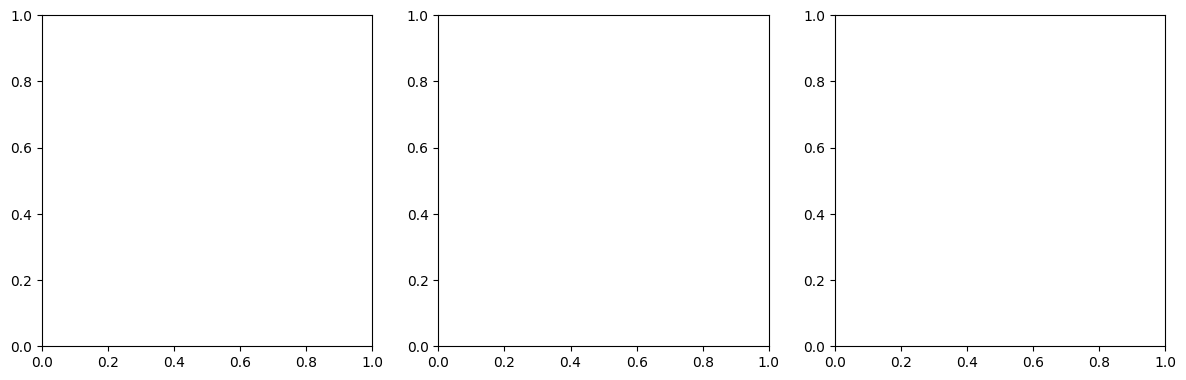

In [7]:
color_map = {
    "k0_250": "magenta",
    "k0_280": "royalblue",
    "k0_315": "darkgreen",
}

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), sharex=True)

for label, curve in curve_map.items():
    df = curves_df[curves_df["label"] == label].copy()
    color = color_map.get(label, None)
    title_label = label.replace("_", " ")

    axes[0].plot(df["n_over_n0"], df["energy_per_baryon_minus_mn"], lw=1.4, color=color, label=title_label)
    axes[1].plot(df["n_over_n0"], df["quark_fraction"], lw=1.4, color=color, label=title_label)
    axes[2].plot(df["n_over_n0"], df["vs2"], lw=1.4, color=color, label=title_label)

axes[0].set_ylabel(r"$\epsilon / n_B - m_N$ [MeV]")
axes[0].set_xlabel(r"$n_B/n_0$")

axes[1].set_ylabel(r"$f_Q$")
axes[1].set_xlabel(r"$n_B/n_0$")

axes[2].axhline(1.0 / 3.0, color="0.5", ls=":", lw=1.0)
axes[2].axhline(1.0, color="0.75", ls="--", lw=1.0)
axes[2].set_ylabel(r"$v_s^2$")
axes[2].set_xlabel(r"$n_B/n_0$")

for ax in axes:
    ax.grid(True, ls="--", lw=0.5, alpha=0.6)
    ax.legend(frameon=False)
    ax.set_xlim(0.0, 5.0)

plt.tight_layout()
plt.show()


In [ ]:
for label, curve in curve_map.items():
    df = curves_df[curves_df["label"] == label].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1), sharex=True)
    fig.suptitle(label.replace("_", " "))

    axes[0].plot(df["n_over_n0"], df["energy_per_baryon_minus_mn"], color="black", lw=1.3)
    axes[0].plot(df["n_over_n0"], df["P"], color="tab:red", lw=1.1)
    axes[0].set_ylabel(r"$\epsilon / n_B - m_N$ [MeV],  $P$ [MeV fm$^{-3}$]")
    axes[0].set_xlabel(r"$n_B/n_0$")

    axes[1].plot(df["n_over_n0"], df["quark_fraction"], color="tab:blue", lw=1.3, label=r"$f_Q$")
    axes[1].plot(df["n_over_n0"], df["vs2"], color="tab:green", lw=1.3, label=r"$v_s^2$")
    axes[1].axhline(1.0 / 3.0, color="0.5", ls=":", lw=1.0)
    axes[1].axhline(1.0, color="0.75", ls="--", lw=1.0)
    axes[1].set_ylabel(r"$f_Q$, $v_s^2$")
    axes[1].set_xlabel(r"$n_B/n_0$")

    for ax in axes:
        ax.grid(True, ls="--", lw=0.5, alpha=0.6)
        ax.set_xlim(0.0, 5.0)

    axes[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()


Notes:

- This is the **symmetric** Clausius case only.
- The selected branches are labeled by the target incompressibility `K0` used to determine the corresponding Clausius parameter `c`.
- The generated CSV files are written to `nuclear_matter_workflows/results/symmetric_clausius_quarkyonic_outputs/`.
